In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [2]:
# ── 1. LOAD DATA
df = pd.read_csv('Telco-Customer-Churn.csv')
print(df.shape)       # (7043, 21), original dataset.
print(df.head())
print(df.info())

(7043, 21)
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Co

In [3]:
## For PPT Data Preview
key_cols = ['gender', 'SeniorCitizen', 'tenure', 'Contract', 'MonthlyCharges', 'Churn']

styled = (df[key_cols].head(5)
    .style
    .set_caption("Sample Customer Data (5 rows)")
    .highlight_null(color='lightcoral')           # highlight any NaN in red
    .applymap(lambda v: 'color: red; font-weight: bold'
              if v == 'Yes' else '', subset=['Churn'])  # highlight churners
    .format({'MonthlyCharges': '${:.2f}'})        # format money nicely
)

styled


C:\Users\Arij\AppData\Local\Temp\ipykernel_11744\2246363838.py:8: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(lambda v: 'color: red; font-weight: bold'


,gender,SeniorCitizen,tenure,Contract,MonthlyCharges,Churn
0,Female,0,1,Month-to-month,$29.85,No
1,Male,0,34,One year,$56.95,No
2,Male,0,2,Month-to-month,$53.85,Yes
3,Male,0,45,One year,$42.30,No
4,Female,0,2,Month-to-month,$70.70,Yes


In [4]:
# ── 2. ENCODE CATEGORICAL → NUMERIC 
# Convert Churn to binary: Yes=1, No=0
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [5]:
# Check class distribution

churn_rate = df['Churn'].value_counts(normalize=True) * 100
print(churn_rate)

Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64


In [6]:
# ── 3. DROP UNNECESSARY COLUMNS

# Drop CustomerID (not useful for ML)
df.drop('customerID', axis=1, inplace=True)

# Drop TotalCharges (Collinear with MonthlyCharges)
df.drop('TotalCharges', axis=1, inplace=True)


In [8]:
# One-hot encode all remaining categorical columns
df_encoded = pd.get_dummies(df)
print(df_encoded.shape)

# final dataset ready for modelling contains 46 features (after encoding)
print(df_encoded.head())


print(df_encoded) 

(7043, 45)
   SeniorCitizen  tenure  MonthlyCharges  Churn  gender_Female  gender_Male  \
0              0       1           29.85      0           True        False   
1              0      34           56.95      0          False         True   
2              0       2           53.85      1          False         True   
3              0      45           42.30      0          False         True   
4              0       2           70.70      1           True        False   

   Partner_No  Partner_Yes  Dependents_No  Dependents_Yes  ...  \
0       False         True           True           False  ...   
1        True        False           True           False  ...   
2        True        False           True           False  ...   
3        True        False           True           False  ...   
4        True        False           True           False  ...   

   StreamingMovies_Yes  Contract_Month-to-month  Contract_One year  \
0                False                     True

In [11]:
# Drop the one-hot encoded columns for Churn since we already have the binary 'Churn' column
df_encoded = df_encoded.drop(columns=['Churn_label_Stayed', 'Churn_label_Churned'], errors='ignore')

In [12]:
print(df_encoded) 

      SeniorCitizen  tenure  MonthlyCharges  Churn  gender_Female  \
0                 0       1           29.85      0           True   
1                 0      34           56.95      0          False   
2                 0       2           53.85      1          False   
3                 0      45           42.30      0          False   
4                 0       2           70.70      1           True   
...             ...     ...             ...    ...            ...   
7038              0      24           84.80      0          False   
7039              0      72          103.20      0           True   
7040              0      11           29.60      0           True   
7041              1       4           74.40      1          False   
7042              0      66          105.65      0          False   

      gender_Male  Partner_No  Partner_Yes  Dependents_No  Dependents_Yes  \
0           False       False         True           True           False   
1            True

#### EDA Visualization

C:\Users\Arij\AppData\Local\Temp\ipykernel_11744\480664907.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bar_plot1=sns.barplot(


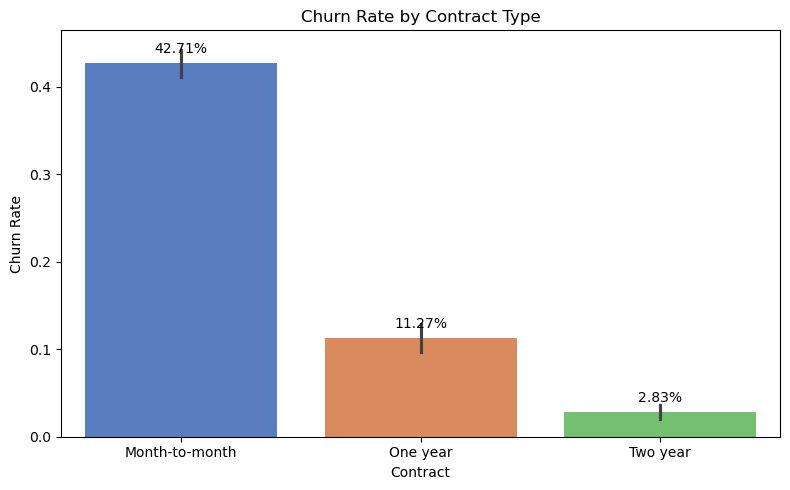

In [13]:
# --- Churn by Contract Type (Bar Chart) ---

plt.figure(figsize=(8, 5))

bar_plot1=sns.barplot(
    x='Contract',
    y='Churn',
    data=df,
    palette='muted'
)

for bar in bar_plot1.patches:
    height = bar.get_height()
    bar_plot1.annotate(f'{height:.2%}',  # format as percentage
                       xy=(bar.get_x() + bar.get_width() / 2, height),
                       xytext=(0, 5),  # offset text above bar
                       textcoords='offset points',
                       ha='center', va='bottom',
                       fontsize=10
                       )
     
plt.title('Churn Rate by Contract Type')
plt.ylabel('Churn Rate')
plt.tight_layout()
plt.show()


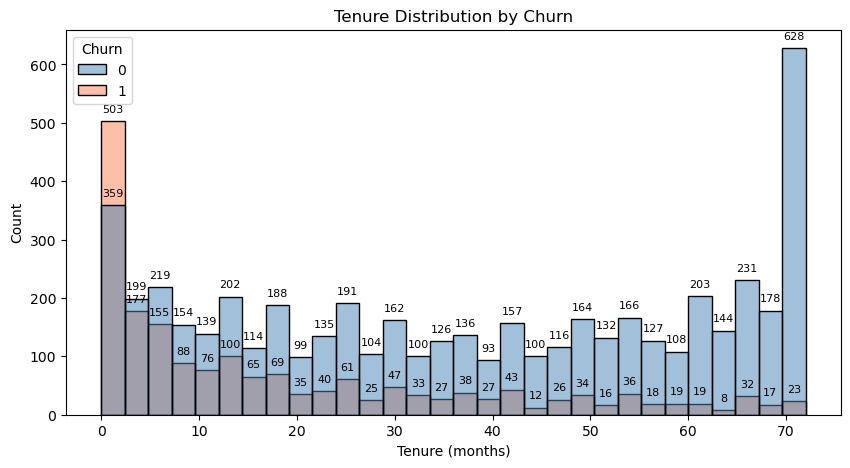

In [10]:
# ---  Tenure Distribution by Churn ---
plt.figure(figsize=(10, 5))
hist_plot1=sns.histplot(data=df, x='tenure', hue='Churn', bins=30,
             palette=['steelblue', 'coral'])
for bar in hist_plot1.patches:
    height = bar.get_height()
    hist_plot1.annotate(f'{height:.0f}',  # show count
                       xy=(bar.get_x() + bar.get_width() / 2, height),
                       xytext=(0, 5),  # offset text above bar
                       textcoords='offset points',
                       ha='center', va='bottom',
                       fontsize=8
                       )
plt.title('Tenure Distribution by Churn')
plt.xlabel('Tenure (months)')
plt.savefig('tenure_churn.png')
plt.show()

C:\Users\Arij\AppData\Local\Temp\ipykernel_11744\1639312833.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


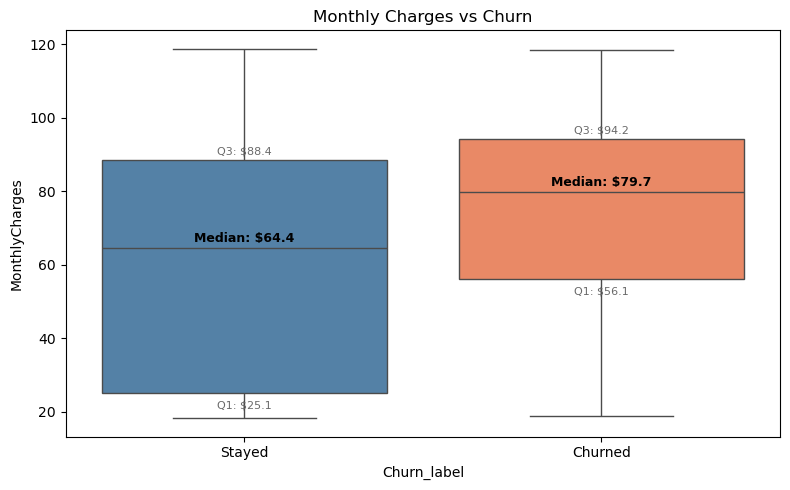

In [14]:
# ---  Monthly Charges by Churn ---

plt.figure(figsize=(8, 5))

df['Churn_label'] = df['Churn'].map({1: 'Churned', 0: 'Stayed'})

ax = sns.boxplot(
    x='Churn_label', y='MonthlyCharges', data=df,
    palette=['steelblue', 'coral']
)

# Calculate stats per group in the SAME order as the plot
groups = ['Stayed', 'Churned']

for i, group in enumerate(groups):
    group_data = df[df['Churn_label'] == group]['MonthlyCharges']
    
    median = group_data.median()
    q1     = group_data.quantile(0.25)
    q3     = group_data.quantile(0.75)

    # Annotate median (inside box, middle line)
    ax.text(i, median + 1, f'Median: ${median:.1f}',
            ha='center', va='bottom', fontsize=9, color='black', fontweight='bold')

    # Annotate Q1 (bottom of box)
    ax.text(i, q1 - 2, f'Q1: ${q1:.1f}',
            ha='center', va='top', fontsize=8, color='dimgray')

    # Annotate Q3 (top of box)
    ax.text(i, q3 + 1, f'Q3: ${q3:.1f}',
            ha='center', va='bottom', fontsize=8, color='dimgray')

plt.title('Monthly Charges vs Churn')
plt.tight_layout()
plt.savefig('monthly_charges_churn.png')
plt.show()


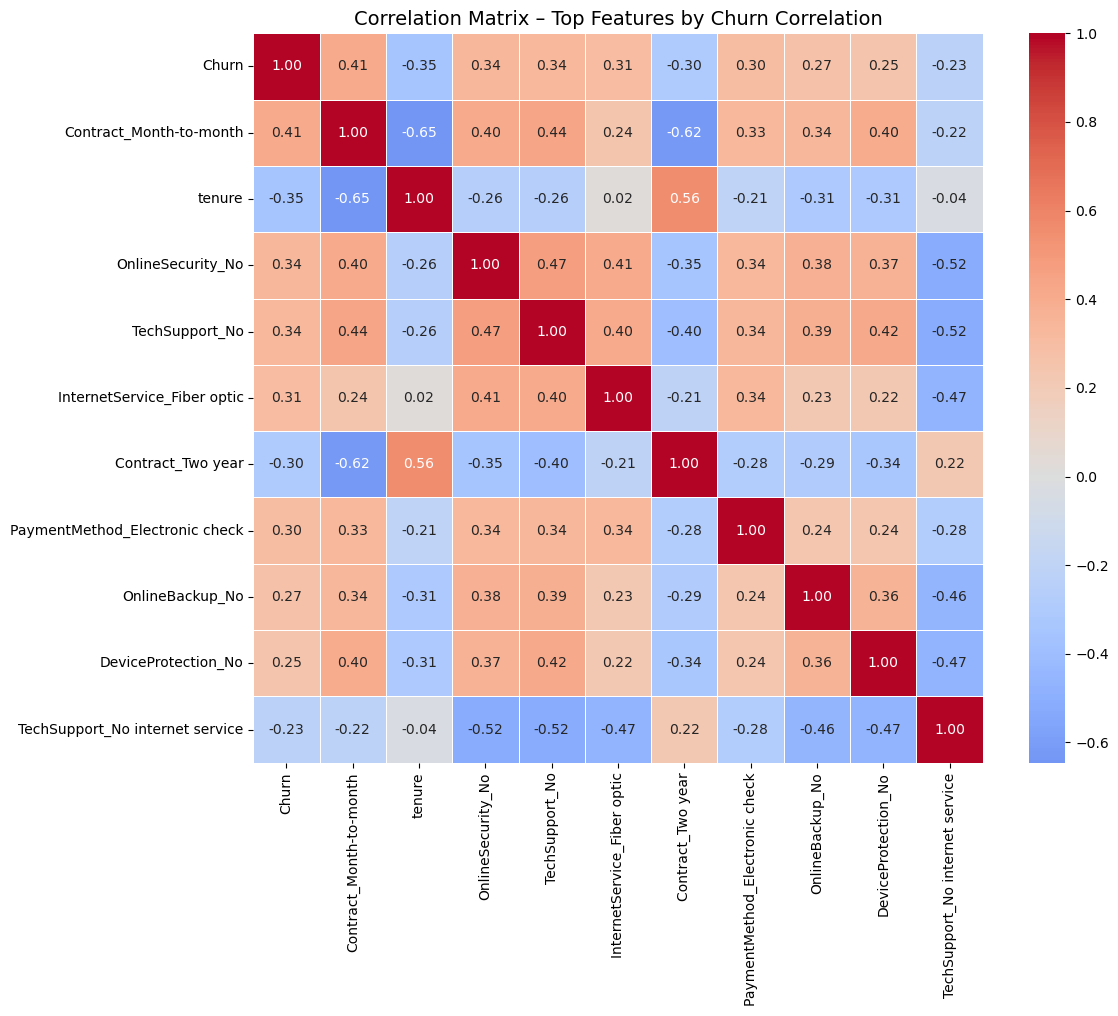

In [15]:
# Pick top N features most correlated with Churn
top_features = (
    df_encoded.corr()['Churn']
    .abs()                          # use absolute value so negatives count too
    .sort_values(ascending=False)
    .head(11)                       
    .index.tolist()
)

corr_matrix = df_encoded[top_features].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,               
    linewidths=0.5,
    square=True,            
    mask=False   )           
plt.title('Correlation Matrix – Top Features by Churn Correlation', fontsize=14)
plt.tight_layout()
plt.savefig('heatmap_correlation.png', dpi=150)
plt.show()

#### Data Split

In [16]:
# ── 4. TRAIN / VALIDATION / TEST SPLIT
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

In [17]:
# Step 1: split off 10% test set
X_remaining, X_test, y_remaining, y_test = train_test_split(
    X, y, test_size=0.10, random_state=42, stratify=y 
)

# Step 2: split remaining into 80% train, 10% val
X_train, X_val, y_train, y_val = train_test_split(
    X_remaining, y_remaining, test_size=0.111, random_state=42, stratify=y_remaining
)

print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

Train: 5634, Val: 704, Test: 705


#### Checking y value

In [18]:
# Check and fix NaN in y
print("NaN in y_train:", y_train.isna().sum())
print("NaN in y_val:", y_val.isna().sum())

# Fix: drop NaN rows
y_train = y_train.dropna()
X_train = X_train.loc[y_train.index]

y_val = y_val.dropna()
X_val = X_val.loc[y_val.index]

print("Fixed! y_train values:", y_train.unique())

NaN in y_train: 0
NaN in y_val: 0
Fixed! y_train values: [0 1]


### ML Starts here
#### Pipeline

In [19]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report


# X_train, X_val, X_test, y_train, y_val, y_test already defined above

# --- Define 3 pipelines
pipelines = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=1000, class_weight='balanced'))
    ]),
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('model', RandomForestClassifier(
            n_estimators=200, max_depth=10,
            min_samples_split=5, class_weight='balanced', random_state=42
        ))  # ← your GridSearch best params!
    ]),
    'Decision Tree': Pipeline([
        ('model', DecisionTreeClassifier(
            max_depth=5,
            min_samples_split=20,
            min_samples_leaf=10,
            class_weight='balanced',
            random_state=42
        ))
    ])
}

# --- Train on X_train, evaluate on X_val ---
for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    print(f"\n--- {name} ---")
    print(classification_report(y_val, pipe.predict(X_val)))


--- Logistic Regression ---
              precision    recall  f1-score   support

           0       0.92      0.75      0.82       517
           1       0.54      0.81      0.65       187

    accuracy                           0.77       704
   macro avg       0.73      0.78      0.74       704
weighted avg       0.82      0.77      0.78       704


--- Random Forest ---
              precision    recall  f1-score   support

           0       0.90      0.80      0.85       517
           1       0.58      0.75      0.65       187

    accuracy                           0.79       704
   macro avg       0.74      0.78      0.75       704
weighted avg       0.81      0.79      0.80       704


--- Decision Tree ---
              precision    recall  f1-score   support

           0       0.91      0.72      0.80       517
           1       0.51      0.80      0.62       187

    accuracy                           0.74       704
   macro avg       0.71      0.76      0.71       704

In [20]:
#  SEARCHING for the best value
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [5, 10, 15, None],
    'n_estimators': [50, 100, 200],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(RandomForestClassifier(), param_grid, cv=5, scoring='f1')
grid_search.fit(X_train, y_train)

print(grid_search.best_params_)

{'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 50}


In [21]:
# Use the best parameters found by GridSearchCV
rf_best = RandomForestClassifier(
    max_depth=10,
    min_samples_split=5,
    n_estimators=50,
    class_weight='balanced',
    random_state=42
)
rf_best.fit(X_train, y_train)

# Evaluate on validation set
from sklearn.metrics import classification_report
print(classification_report(y_val, rf_best.predict(X_val)))

              precision    recall  f1-score   support

           0       0.89      0.79      0.84       517
           1       0.56      0.74      0.64       187

    accuracy                           0.78       704
   macro avg       0.73      0.76      0.74       704
weighted avg       0.80      0.78      0.79       704



In [22]:
# Collect all models
models = {
    'Logistic Regression': pipelines['Logistic Regression'],
    'Random Forest (default)': pipelines['Random Forest'],
    'Decision Tree': pipelines['Decision Tree'],
    'Random Forest (best params)': rf_best  # ← your GridSearch tuned model
}

# Compare on validation set
for name, model in models.items():
    print(f"\n--- {name} ---")
    print(classification_report(y_val, model.predict(X_val)))


--- Logistic Regression ---
              precision    recall  f1-score   support

           0       0.92      0.75      0.82       517
           1       0.54      0.81      0.65       187

    accuracy                           0.77       704
   macro avg       0.73      0.78      0.74       704
weighted avg       0.82      0.77      0.78       704


--- Random Forest (default) ---
              precision    recall  f1-score   support

           0       0.90      0.80      0.85       517
           1       0.58      0.75      0.65       187

    accuracy                           0.79       704
   macro avg       0.74      0.78      0.75       704
weighted avg       0.81      0.79      0.80       704


--- Decision Tree ---
              precision    recall  f1-score   support

           0       0.91      0.72      0.80       517
           1       0.51      0.80      0.62       187

    accuracy                           0.74       704
   macro avg       0.71      0.76      0.71

#### Try Boosting Models

In [23]:
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Add boosting models to your pipelines dict
boosting_pipelines = {
    'AdaBoost': Pipeline([
        ('scaler', StandardScaler()),
        ('model', AdaBoostClassifier(n_estimators=100, random_state=42))
    ]),
    'Gradient Boosting': Pipeline([
        ('scaler', StandardScaler()),
        ('model', GradientBoostingClassifier(n_estimators=100, random_state=42))
    ]),
    'XGBoost': Pipeline([
        ('scaler', StandardScaler()),
        ('model', XGBClassifier(n_estimators=100, random_state=42,
                                eval_metric='logloss', scale_pos_weight=3, verbosity=0))
    ]),
    'LightGBM': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LGBMClassifier(n_estimators=100, random_state=42, class_weight='balanced', verbose=-1))
    ])
}

# Train and evaluate on validation set
for name, pipe in boosting_pipelines.items():
    pipe.fit(X_train, y_train)
    print(f"\n--- {name} ---")
    print(classification_report(y_val, pipe.predict(X_val)))


--- AdaBoost ---
              precision    recall  f1-score   support

           0       0.85      0.91      0.88       517
           1       0.70      0.56      0.62       187

    accuracy                           0.82       704
   macro avg       0.78      0.74      0.75       704
weighted avg       0.81      0.82      0.81       704


--- Gradient Boosting ---
              precision    recall  f1-score   support

           0       0.83      0.92      0.87       517
           1       0.69      0.49      0.57       187

    accuracy                           0.81       704
   macro avg       0.76      0.70      0.72       704
weighted avg       0.79      0.81      0.79       704


--- XGBoost ---
              precision    recall  f1-score   support

           0       0.87      0.79      0.83       517
           1       0.54      0.68      0.61       187

    accuracy                           0.76       704
   macro avg       0.71      0.74      0.72       704
weighted avg

c:\Users\Arij\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LR  AUC: 0.851
RF  AUC: 0.85
DT  AUC: 0.839


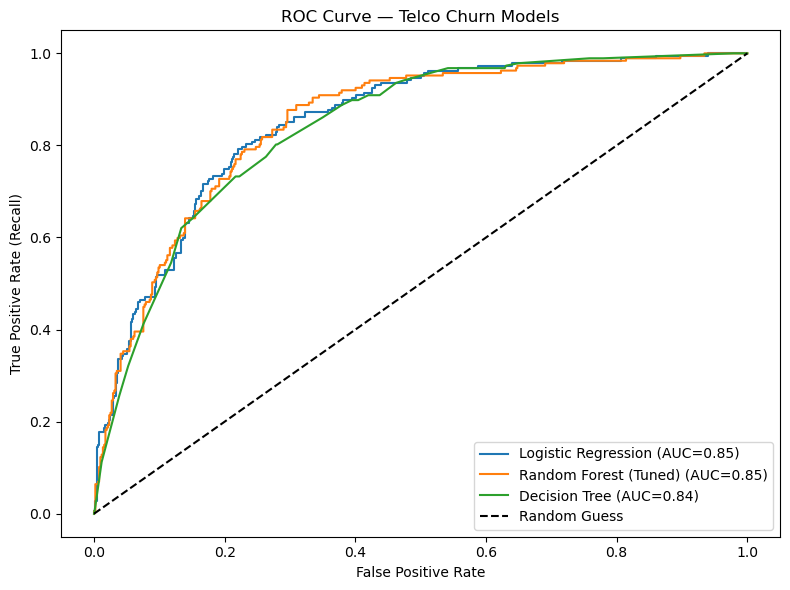

In [42]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

#  Use pipelines + rf_best
lr_probs = pipelines['Logistic Regression'].predict_proba(X_val)[:, 1]
rf_probs = rf_best.predict_proba(X_val)[:, 1]
dt_probs = pipelines['Decision Tree'].predict_proba(X_val)[:, 1]

# AUC scores
print("LR  AUC:", round(roc_auc_score(y_val, lr_probs), 3))
print("RF  AUC:", round(roc_auc_score(y_val, rf_probs), 3))
print("DT  AUC:", round(roc_auc_score(y_val, dt_probs), 3))

# Plot all 3 curves
plt.figure(figsize=(8, 6))
for name, probs in [("Logistic Regression", lr_probs),
                    ("Random Forest (Tuned)", rf_probs),
                    ("Decision Tree", dt_probs)]:
    fpr, tpr, _ = roc_curve(y_val, probs)
    auc = roc_auc_score(y_val, probs)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve — Telco Churn Models")
plt.legend()
plt.tight_layout()
plt.savefig("roc_curve_validation.png")
plt.show()

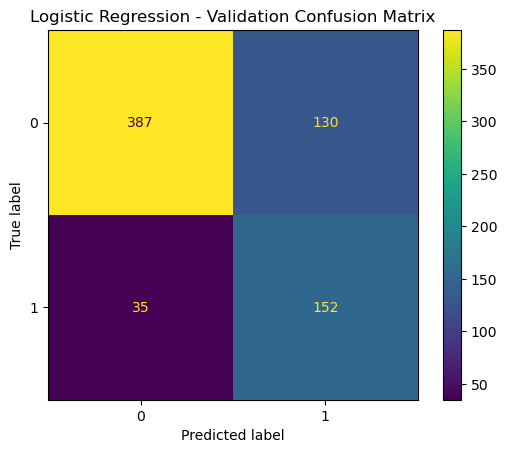

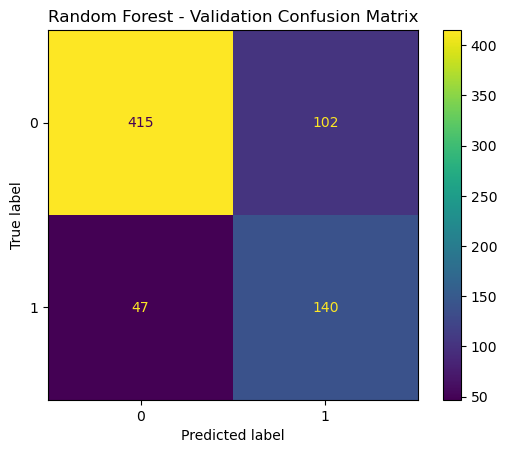

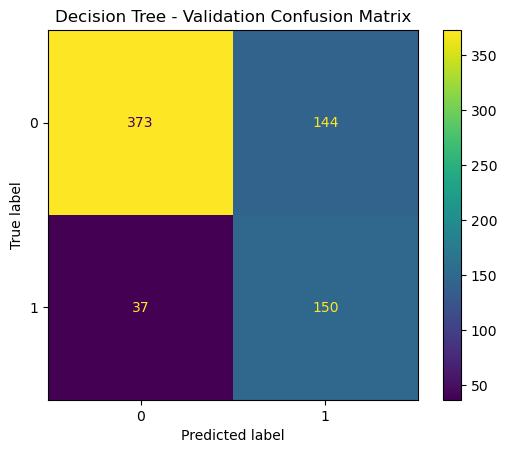

In [41]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Validation Confusion Matrices for all models

for name, pipe in pipelines.items():
    # Validation predictions
    y_val_pred = pipe.predict(X_val)
    
    # Compute confusion matrix
    cm_val = confusion_matrix(y_val, y_val_pred)
    
    # Display
    ConfusionMatrixDisplay(cm_val).plot()
    plt.title(f"{name} - Validation Confusion Matrix")
    plt.savefig(f"{name} - Validation Confusion Matrix")
    plt.show()

In [35]:
print("--- FINAL TEST: Logistic Regression ---")
print(classification_report(y_test, pipelines['Logistic Regression'].predict(X_test)))

--- FINAL TEST: Logistic Regression ---
              precision    recall  f1-score   support

           0       0.90      0.74      0.81       518
           1       0.52      0.76      0.62       187

    accuracy                           0.75       705
   macro avg       0.71      0.75      0.72       705
weighted avg       0.80      0.75      0.76       705



Feature Importances (Logistic Regression):


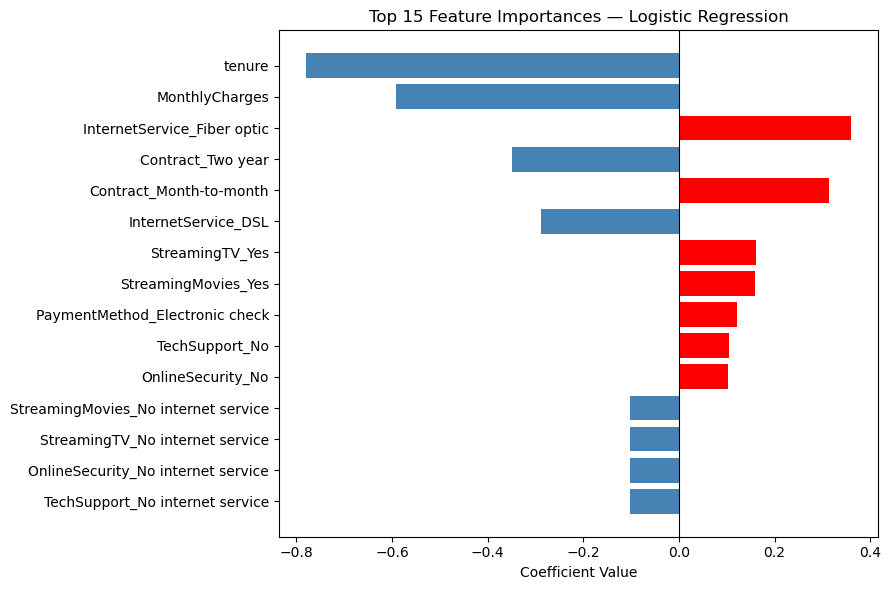

In [36]:
import numpy as np

model = pipelines['Logistic Regression'].named_steps['model']

all_features = X_train.columns.tolist()

# Build DataFrame of coefficients
feat_df = pd.DataFrame({
    'Feature': all_features,
    'Coefficient': model.coef_[0]
})

# Sort by absolute value, take top 15
feat_df['abs_coef'] = feat_df['Coefficient'].abs()
feat_df = feat_df.sort_values('abs_coef', ascending=False).head(15)

print('Feature Importances (Logistic Regression):')

# Plot
colors = ['red' if c > 0 else 'steelblue' for c in feat_df['Coefficient']]
plt.figure(figsize=(9, 6))
plt.barh(feat_df['Feature'][::-1], feat_df['Coefficient'][::-1], color=colors[::-1])
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel("Coefficient Value")
plt.title("Top 15 Feature Importances — Logistic Regression")
plt.tight_layout()
plt.savefig("feature_importance.png")
plt.show()

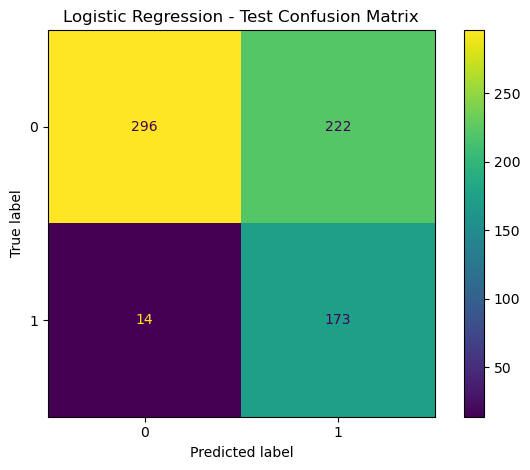

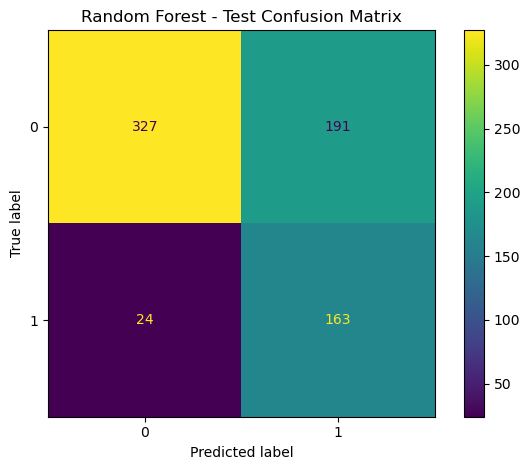

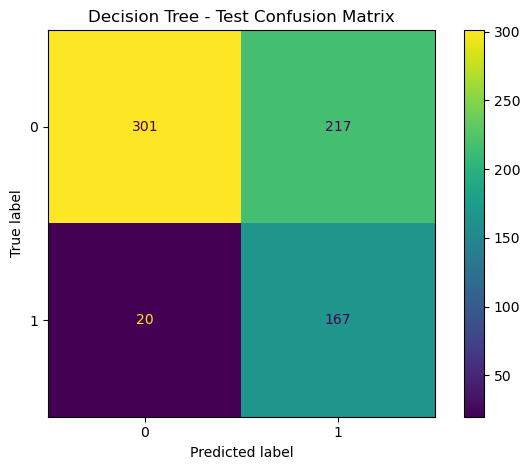

In [40]:
# Confusion Matrices test set for all models


for name, pipe in pipelines.items():
    y_probs = pipe.predict_proba(X_test)[:, 1]
    
    threshold = 0.3   # you can tune this
    y_test_pred = (y_probs >= threshold).astype(int)
    
    # Compute confusion matrix
    cm_test = confusion_matrix(y_test, y_test_pred)
    
    # Display
    ConfusionMatrixDisplay(cm_test).plot()
    plt.title(f"{name} - Test Confusion Matrix")
    plt.tight_layout()
    plt.savefig(f"{name} - Test Confusion Matrix")
    plt.show()

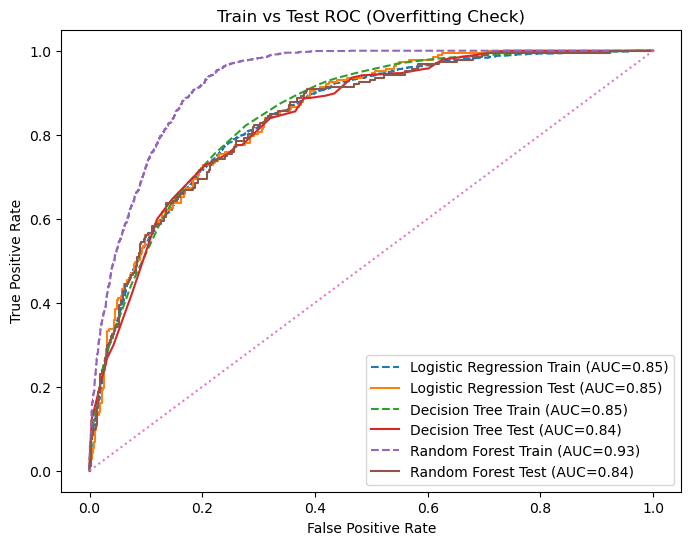

In [43]:
# ROC Curves for Train vs Test (Overfitting Check)

#  Train models
pipelines['Logistic Regression'].fit(X_train, y_train)
pipelines['Decision Tree'].fit(X_train, y_train)
rf_best.fit(X_train, y_train)

models = {
    "Logistic Regression": pipelines['Logistic Regression'],
    "Decision Tree": pipelines['Decision Tree'],
    "Random Forest": rf_best
}

#  Plot
plt.figure(figsize=(8,6))

for name, model in models.items():
    # --- TRAIN ROC ---
    y_train_proba = model.predict_proba(X_train)[:, 1]
    fpr_train, tpr_train, _ = roc_curve(y_train, y_train_proba)
    auc_train = roc_auc_score(y_train, y_train_proba)
    
    # --- TEST ROC (out-of-sample) ---
    y_test_proba = model.predict_proba(X_test)[:, 1]
    fpr_test, tpr_test, _ = roc_curve(y_test, y_test_proba)
    auc_test = roc_auc_score(y_test, y_test_proba)
    
    # Plot both
    plt.plot(fpr_train, tpr_train, linestyle='--',
             label=f"{name} Train (AUC={auc_train:.2f})")
    
    plt.plot(fpr_test, tpr_test,
             label=f"{name} Test (AUC={auc_test:.2f})")

# Baseline
plt.plot([0,1], [0,1], linestyle=':')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Train vs Test ROC (Overfitting Check)")
plt.legend()
plt.savefig("roc_curve_train_vs_test")
plt.show()

In [39]:
# Calculate AUC scores and overfitting gap

from sklearn.metrics import roc_auc_score

results = []

for name, model in models.items():
    # --- TRAIN (in-sample) ---
    y_train_proba = model.predict_proba(X_train)[:, 1]
    auc_train = roc_auc_score(y_train, y_train_proba)
    
    # --- TEST (out-of-sample) ---
    y_test_proba = model.predict_proba(X_test)[:, 1]
    auc_test = roc_auc_score(y_test, y_test_proba)
    
    # Gap
    gap = auc_train - auc_test
    
    results.append({
        "Model": name,
        "Train AUC": round(auc_train, 3),
        "Test AUC": round(auc_test, 3),
        "Overfitting Gap": round(gap, 3)
    })

results_df = pd.DataFrame(results)
print(results_df)

                 Model  Train AUC  Test AUC  Overfitting Gap
0  Logistic Regression      0.845     0.849           -0.004
1        Decision Tree      0.852     0.843            0.009
2        Random Forest      0.929     0.844            0.085


In [22]:
print ("All done! Check the ROC curve, confusion matrix, and feature importance plots for insights.")

All done! Check the ROC curve, confusion matrix, and feature importance plots for insights.
